# Прогнозирование спроса на велопрокат


---

## Описание

### Общая информация

- Заказчик проекта: компания BikeSouth, оператор городского велопроката на черноморском побережье России
- В настоящий момент используется линейная модель машинного обучения (линейную регрессию) для прогнозирования спроса на прокат велосипедов. Существующие решение неудовлетворительно по точности прогнозирования.

### Бизнес задача

- повысить точность предсказаний спроса на прокат велосипедов. Это позволит оптимизировать логистику распределения велосипедов, улучшить клиентский опыт и, как следствие, увеличить прибыль компании. 

### Цель
- разработать нелинейную модель машинного обучения для прогнозирования почасового спроса на прокат велосипедов, исходя из погодных и календарных условий.

### ML задача

Вид задачи:
- тип: обучение с учителем
- подтип: регрессия

Целевая переменная:
- **Rented Bike Count** - количество велосипедов, арендованных за конкретный час

Особенности:
- модель должна учитывать нелинейные взаимосвязи между признаками и целевой переменной 
- ключевые метрики: RMSE, R² и MAE
- предоставлено два датасета: для обучения и для теста

---

## 1. Настройка проекта и загрузка данных 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import requests
from phik import phik_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from typing import Optional, Union, Dict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
import optuna 
from sklearn.preprocessing import FunctionTransformer


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### Загрузка данных и исходной модели

In [4]:
# пути к файлам 
linear_base_model_url: str = 'https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.pkl'
linear_base_model_path: Path = Path("baseline_linear_regression_pipeline.pkl")

train_valid_data_path: str = 'https://code.s3.yandex.net/datasets/ds_s14_train_data.csv'
test_data_path: str = 'https://code.s3.yandex.net/datasets/ds_s14_test_data.csv'

In [5]:
# скачать модель
response = requests.get(linear_base_model_url)
response.raise_for_status()
linear_base_model_path.write_bytes(response.content)


6050

In [6]:
# загрузка базового пайплайна
linear_base_model = joblib.load(filename=linear_base_model_path)
linear_base_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('str_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('ohe_pass', 'passthrough',
                                                  ['Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Morning',
                                                   'Time_Period_Night'])])),
                ('regressor', LinearRegression())])

In [7]:
# загрузка данных
df_train_valid = pd.read_csv(train_valid_data_path)
df_test = pd.read_csv(test_data_path)

In [8]:
df_train_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [9]:
X_train_valid = df_train_valid.drop(columns=['Rented Bike Count'])
y_train_valid = df_train_valid['Rented Bike Count']

In [10]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

In [11]:
df_test.columns

Index(['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day',
       'Time_Period_Evening', 'Time_Period_Late Evening',
       'Time_Period_Morning', 'Time_Period_Night', 'Rented Bike Count'],
      dtype='object')

In [12]:
X_test = df_test.drop(columns=['Rented Bike Count'])
y_test = df_test['Rented Bike Count']

### Оценка предоставленной компанией модели

In [13]:
def calculate_metrics(y_true, y_pred, model_name: str) -> pd.DataFrame:
    """Расчет метрик качества предсказания модели"""
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    result_dict = {
        'name': [model_name],
        'MAE': [round(mae, 2)],
        'RMSE': [round(rmse, 2)],
        'R2': [round(r2, 3)],
    }
    result_df = pd.DataFrame(result_dict)
    return result_df

In [14]:

y_linear_base_test_pred = linear_base_model.predict(X_test)
y_linear_base_test_pred

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


array([ 285.18628659,  -24.33231035,  462.55051809, ...,  408.2870924 ,
        227.34145487, 1266.19535653])

In [15]:
linear_base_metrics_test = calculate_metrics(y_true=y_test, y_pred=y_linear_base_test_pred, model_name='LinearBaseModel')
linear_base_metrics_test

,name,MAE,RMSE,R2
0,LinearBaseModel,312.6,411.56,0.586


In [16]:
y_test.describe()

count    1752.000000
mean      700.586187
std       639.880816
min         0.000000
25%       194.750000
50%       503.500000
75%      1042.000000
max      3380.000000
Name: Rented Bike Count, dtype: float64

#### Анализ:
- средняя абсолютная ошибка MAE = 312.6 и средняя квадратична ошибка RMSE=411 находятся на достаточно высоком уровне относительно характерных значений целевой переменной, что свидетельствует о существенных расхождениях прогноза модели и реальных значений.
- базовая модель описывет менее 0.6 вариации тестовых данных (R2 = 0.586), что говорит о низкой предсказательной способности модели на всем диапазоне значений целевой переменной.

---
## 2. Исследовательский анализ данных 

In [17]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', bool]
NUM_COLS_TYPES = [np.number]

In [18]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

#### Общая информация

In [19]:
df_train_valid.head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [20]:
df_train_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [21]:
cat_cols_names, num_cols_names = get_cat_num_cols(df=df_train_valid)
cat_cols_names, len(cat_cols_names), num_cols_names, len(num_cols_names)

(['Seasons',
  'Holiday',
  'Functioning Day',
  'Time_Period_Evening',
  'Time_Period_Late Evening',
  'Time_Period_Morning',
  'Time_Period_Night'],
 7,
 ['Temperature',
  'Humidity(%)',
  'Wind speed (m/s)',
  'Visibility (10m)',
  'Dew point temperature',
  'Solar Radiation (MJ/m2)',
  'Rainfall(mm)',
  'Snowfall (cm)',
  'Rented Bike Count'],
 9)

In [22]:
df_train_valid.describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


Анализ:
- датасет из 7008 объектов, 15 признаков, 1 целевая переменная 
- 7 категориальных, 8 числовых признаков, целевая переменная в виде числа
- явные пропуски есть среди признаков: Humidity(%), Wind speed (m/s), Visibility (10m),  Solar Radiation (MJ/m2), Rainfall(mm), Snowfall (cm)
- признаки Holiday и Functioning Day являются строками, хотя по смыслу это bool-флаги. Можно преобразовать в количественные переменные [0, 1]
- на первый взгляд аномалий и существенных выбросов в данных нет

#### Явные пропуски пропуски

In [23]:
# явные пропуски
miss_vals = df_train_valid.isna().sum() / len(df_train_valid) * 100.
miss_vals

Temperature                 0.000000
Humidity(%)                 3.567352
Wind speed (m/s)            2.996575
Visibility (10m)            3.695776
Dew point temperature       0.000000
Solar Radiation (MJ/m2)     2.996575
Rainfall(mm)                3.738584
Snowfall (cm)               3.752854
Seasons                     0.000000
Holiday                     0.000000
Functioning Day             0.000000
Time_Period_Evening         0.000000
Time_Period_Late Evening    0.000000
Time_Period_Morning         0.000000
Time_Period_Night           0.000000
Rented Bike Count           0.000000
dtype: float64

In [24]:
# список колонок с явными пропусками
miss_vals[miss_vals.values > 0].index.to_list()

['Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)']

Анализ:

- 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)' имеют явные пропуски. 
- Доля пропусков от 2 до 4%

Рекомендация:
- замена пропусков статистиками распределений: медиана для количественных данных, мода для категорий

#### Неявные пропуски

In [25]:
for name in cat_cols_names:
    display(df_train_valid[name].unique())

array(['Autumn', 'Winter', 'Summer', 'Spring'], dtype=object)

array(['Holiday', 'No Holiday'], dtype=object)

array(['Yes', 'No'], dtype=object)

array([ True, False])

array([False,  True])

array([False,  True])

array([False,  True])

In [26]:
df_train_valid.describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


Вывод:
- среди категориальных признаков неявных пропусков нет
- среди количественных переменных флагов, которые могли бы означать неявные пропуски, не замечено. Т.е. неявных пропусков тоже нет.

#### Дубли

In [27]:
df_train_valid.duplicated().sum()

np.int64(0)

Вывод:
- явных дублей нет

### Распределение данных

In [28]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str,
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""

    sns.countplot(data=df, x=col_name)

    plt.title(f'Распределение признака {col_name} в датасете')
    plt.ylabel('количество')

    plt.show()

In [29]:
def box_plot(df: pd.DataFrame, feat_name: str, units: str, whis: Union[list[float], float] = 1.5):
    sns.boxplot(data=df, x=feat_name, orient="h", whis=whis)
    plt.title(f'Распределение признака {feat_name} в датасете')
    plt.xlabel(f'{units}')
    plt.grid()
    plt.show()

#### Целевая переменная

In [30]:
target_name = 'Rented Bike Count'

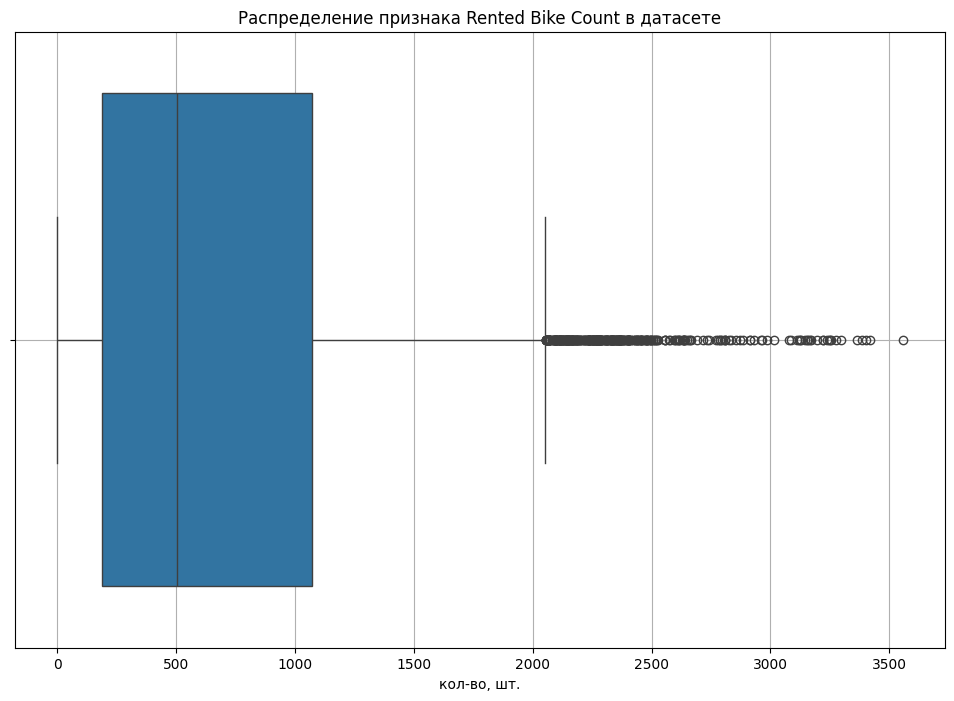

In [31]:
box_plot(df=df_train_valid, feat_name=target_name, units='кол-во, шт.', whis=[0, 95])

In [32]:
df_train_valid[target_name].describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

- распределение целевой переменной несимметрично. 
- 95% данных принадлежит диапазону: 0-2000. 
- малочисленные выбросы (менее 5% данных) распредлелены по диапазону 2000-3556

### Числовые признаки

In [33]:
num_cols_names_feat = [name for name in num_cols_names if name != target_name]
num_cols_names_feat

['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)']

In [34]:
num_cols_names_units = ['градусы, С', 'влажность, %', 'скорость, м/с', 'видимость, 10м', 'градусы, С', 'Мега Джоуль / м2', 'мм', 'см']

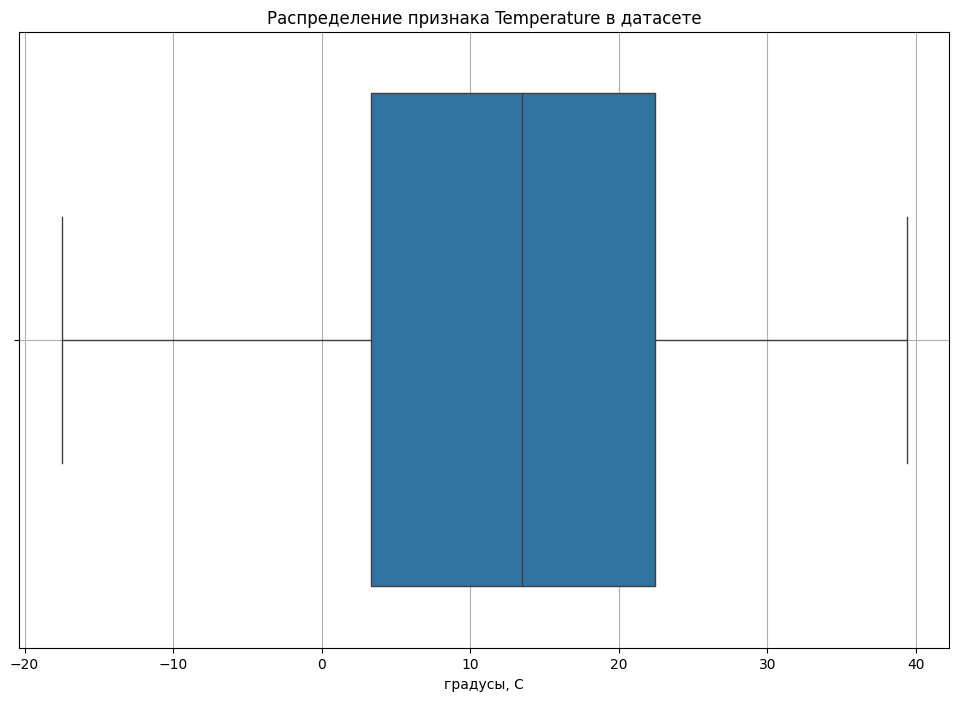

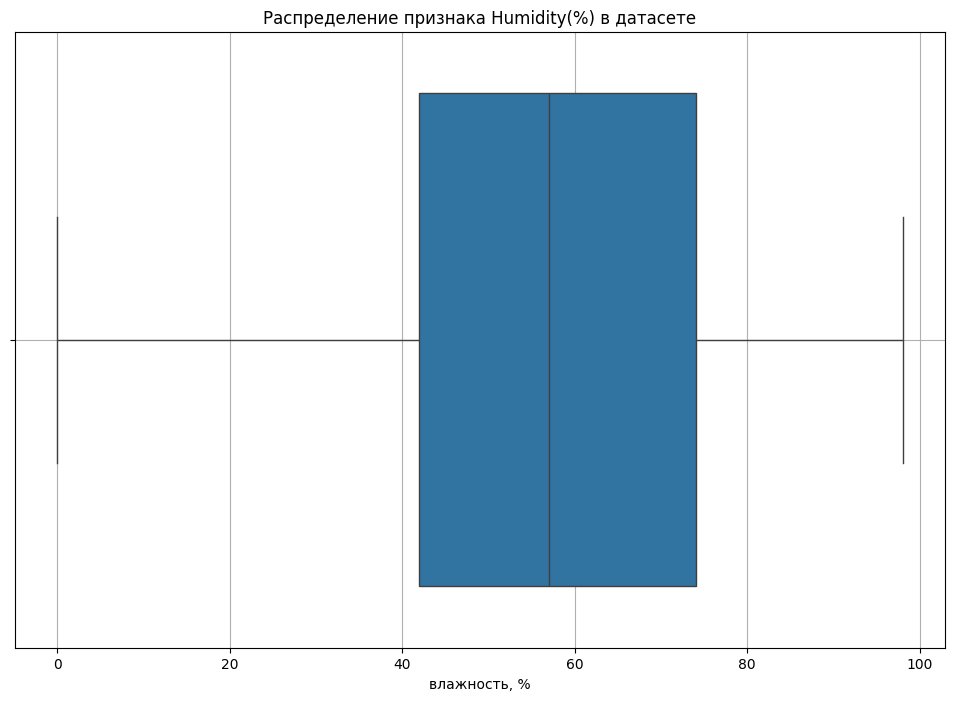

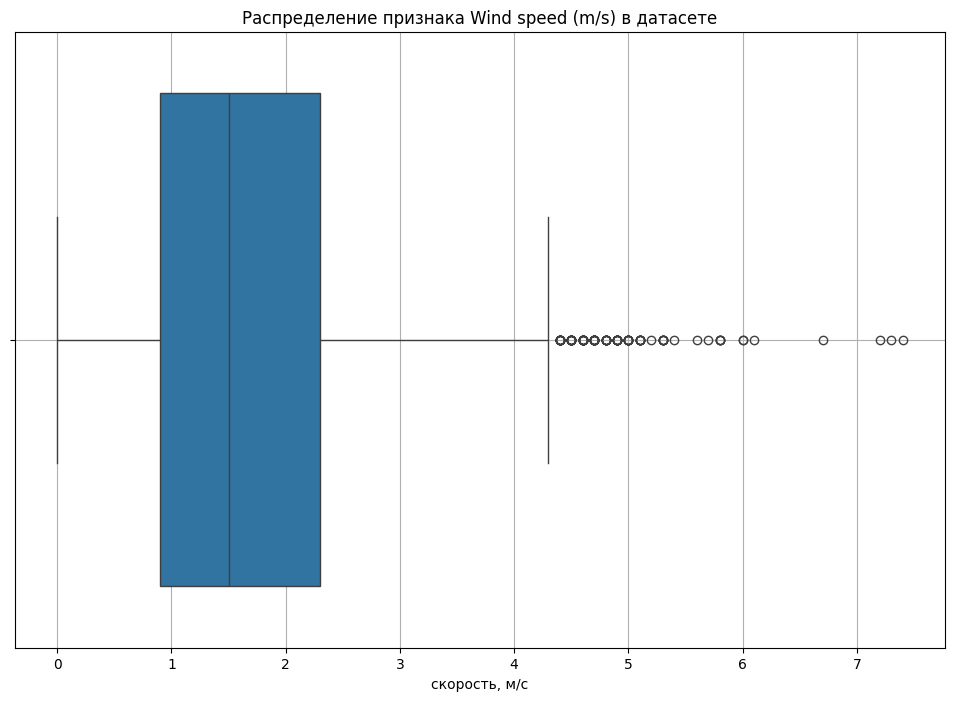

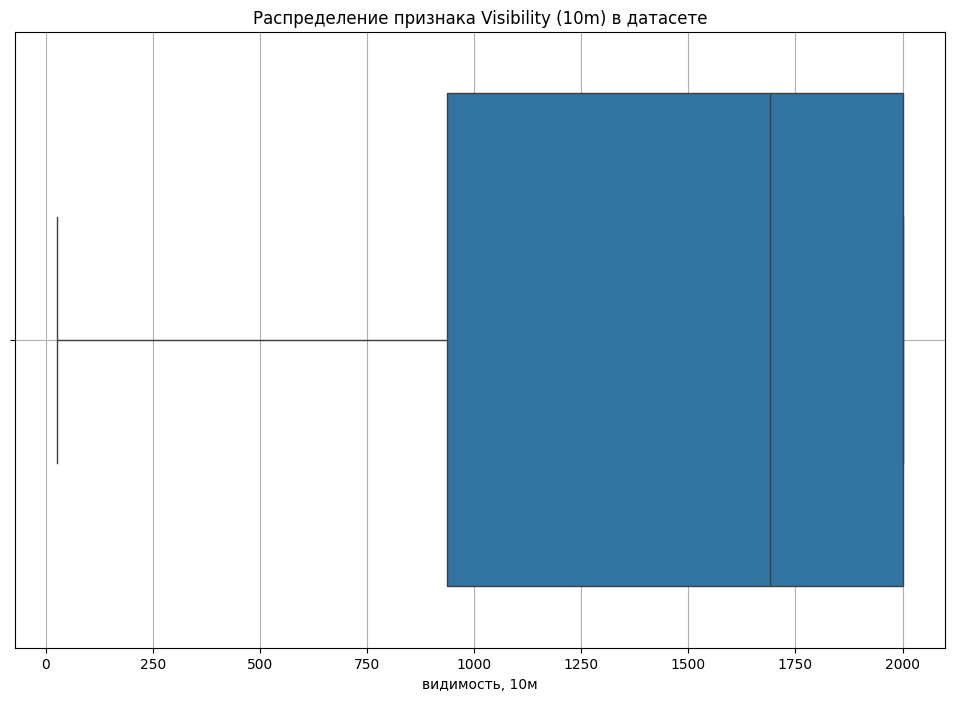

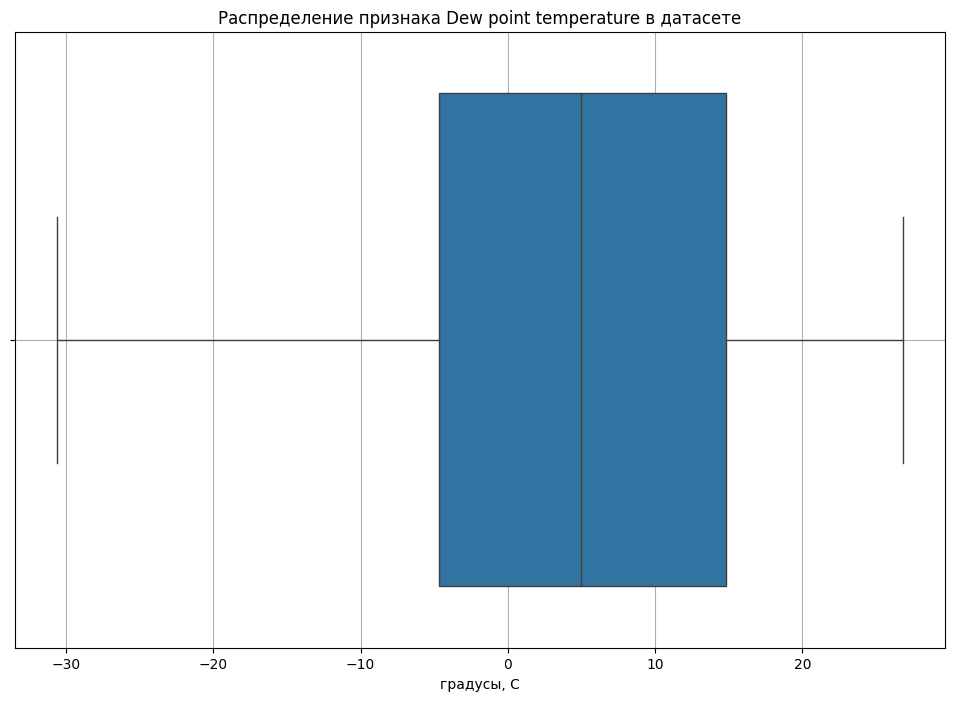

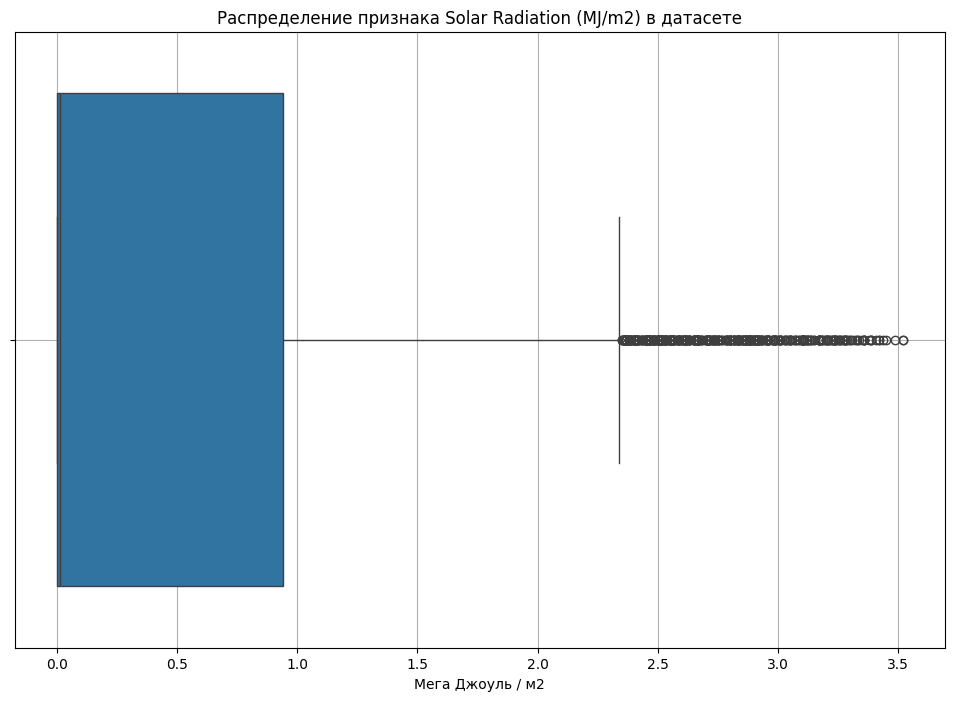

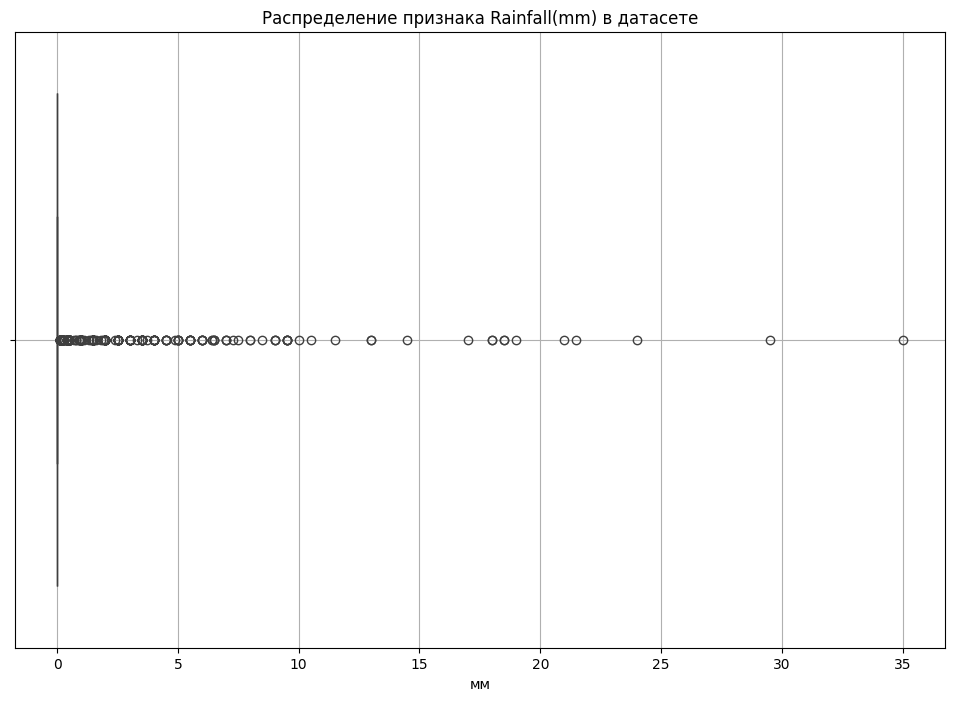

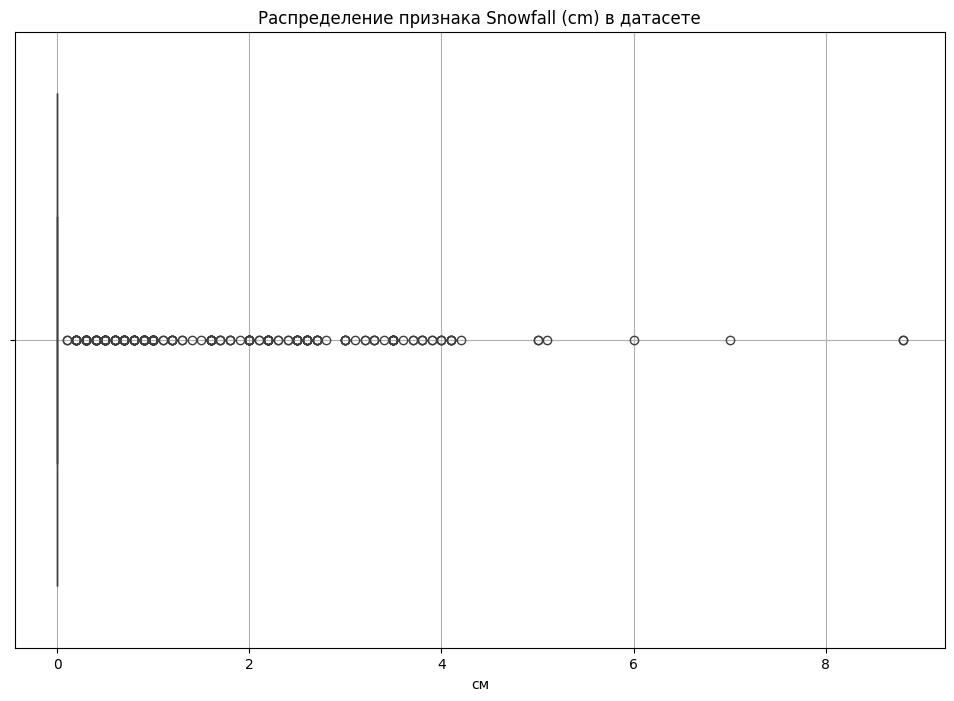

In [35]:
for name, unit in zip(num_cols_names_feat, num_cols_names_units):
    box_plot(df=df_train_valid, feat_name=name, units=unit)

Анализ:
- малочисленные выбросы есть среди значений признаков: 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'
- события дождь и снег - достаточно редкие явления, поэтому среди признаков 'Rainfall(mm)', 'Snowfall (cm)' существенно преобладают нули 

### Категориальные признаки

In [ ]:
# признаки, не требующие предварительных преобразований перед анализом 
cat_cols_names_reg = [
    'Seasons',
    'Holiday',
    'Functioning Day',
 ]

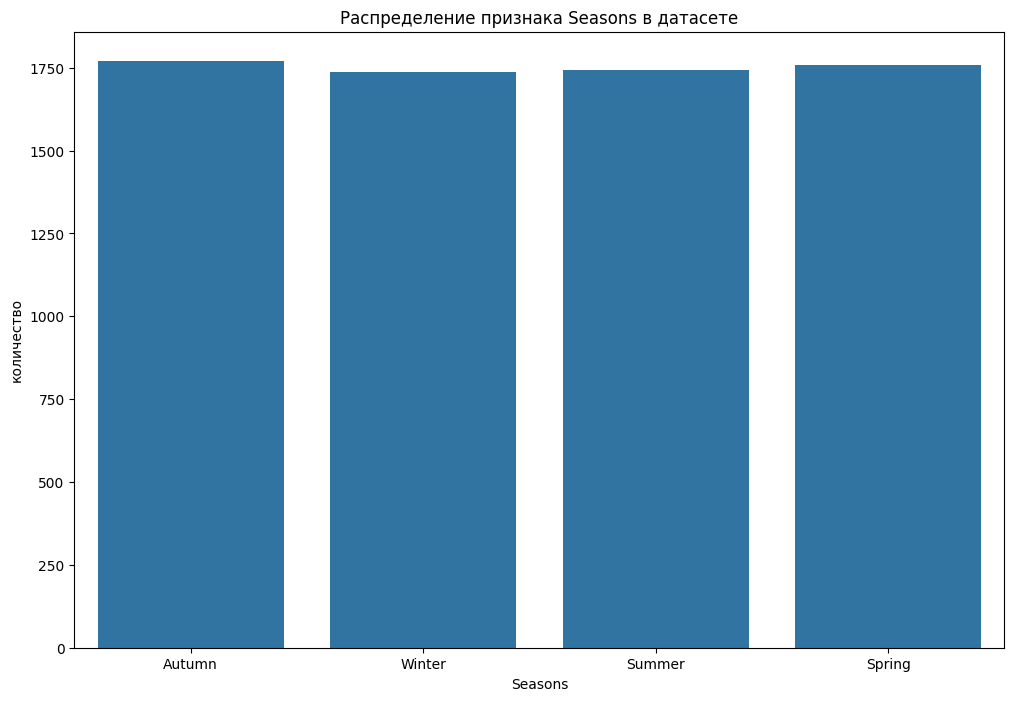

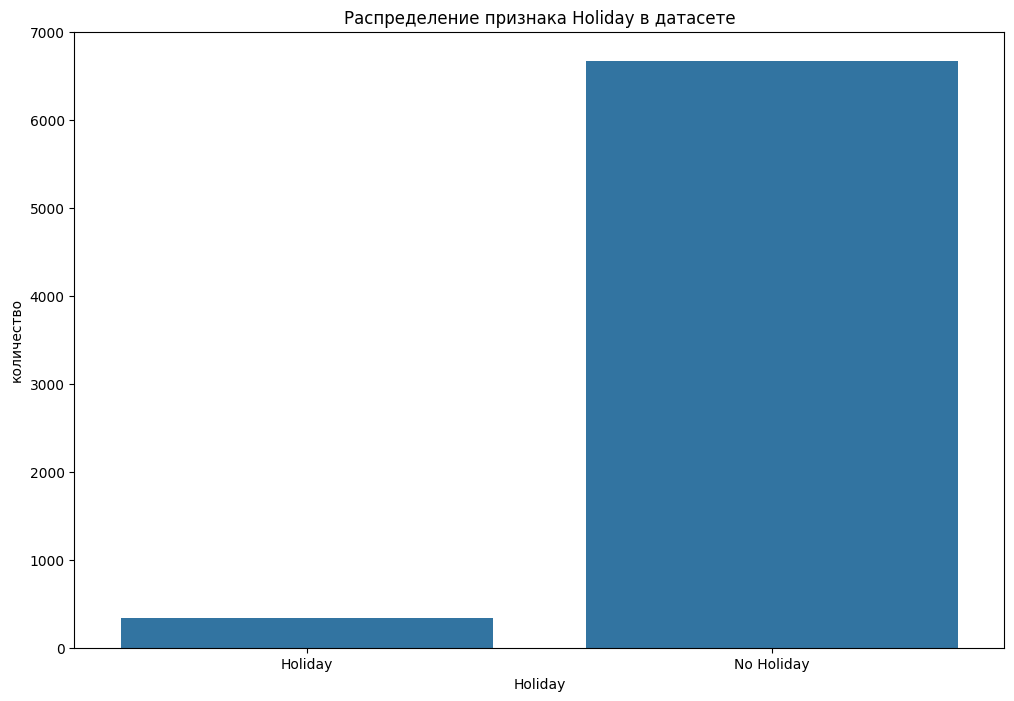

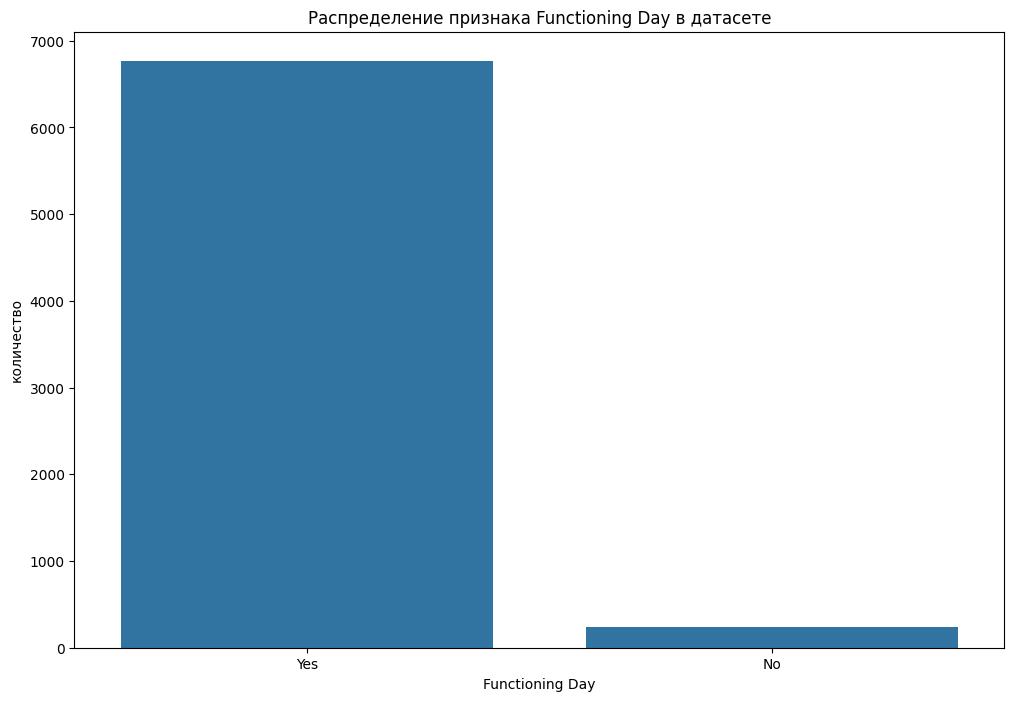

In [37]:
for name in cat_cols_names_reg:
    plot_count_bars(df=df_train_valid, col_name=name)

Анализ:

- времена года 'Seasons' представлены примерно в одинаковом соотношении  
- 'Holiday' - выходных существенно меньше, чем рабочих 
- 'Functioning Day' - аренда происходит преимущественно в рабочее время


In [38]:
# признаки, требующие преобразований перед анализом
cat_col_names_special = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

In [39]:
# доли значений для каждого времени дня
time_period_parts = df_train_valid[cat_col_names_special].sum() / len(df_train_valid)
time_period_parts

Time_Period_Evening         0.166667
Time_Period_Late Evening    0.167380
Time_Period_Morning         0.167237
Time_Period_Night           0.250143
dtype: float64

In [40]:
# доля Daytime
day_time_part = 1. - time_period_parts.values.sum()
day_time_part


np.float64(0.2485730593607307)

Наблюдения:
- доли Evening, Late Evening, Morning близки между собой и составляют 0.16
- доли Night и Daytime близки между собой и составляют 0.25

Выводы:
- люди чаще арендуют ночью и днем, нежели в другие периоды 

### Корреляционный анализ

In [41]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [42]:
corr_matrix = get_corr_matrix(data=df_train_valid, feat_cols=num_cols_names + cat_cols_names, num_cols=num_cols_names)

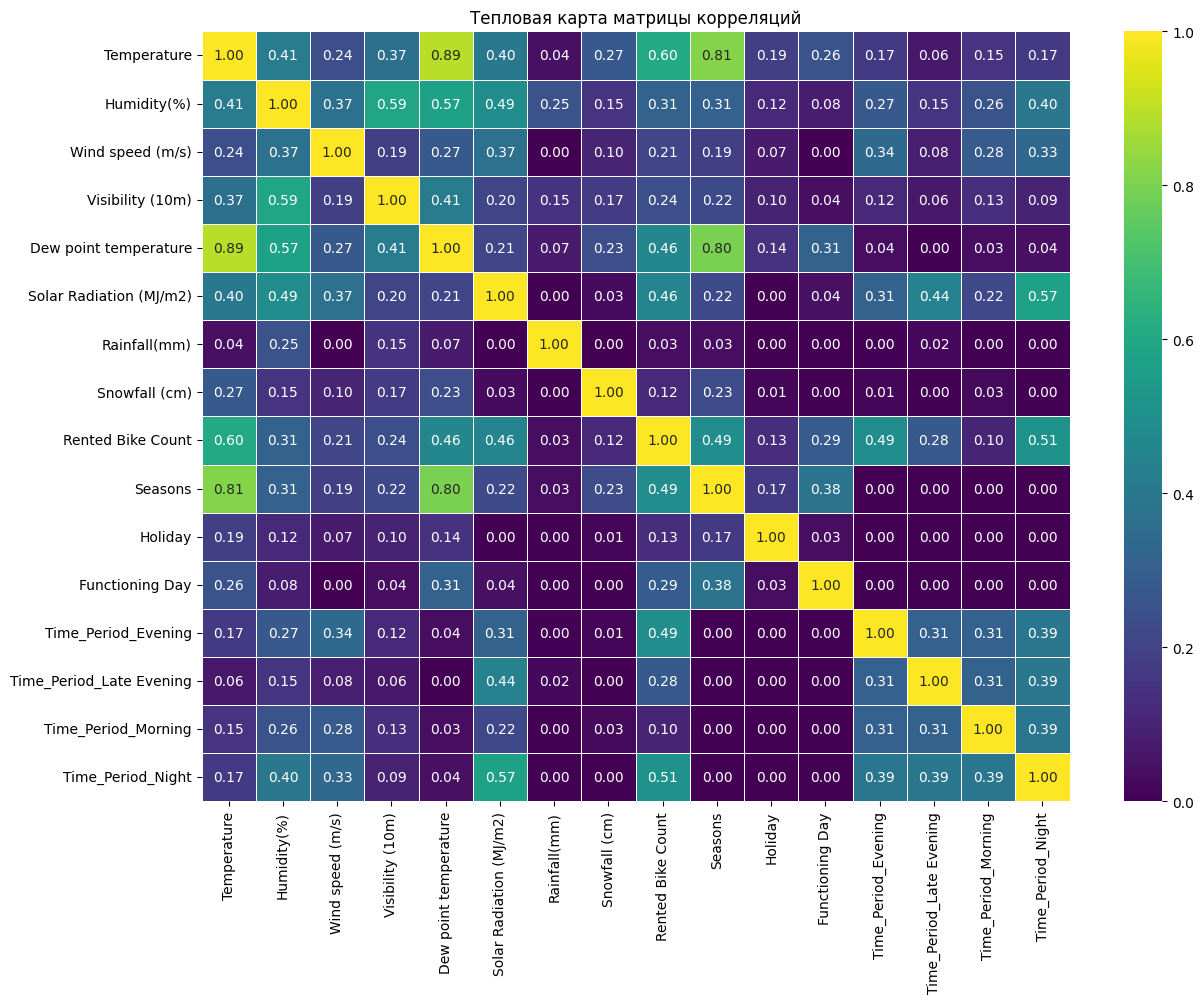

In [43]:
plot_corr_matrix(corr_matrix)

In [44]:
corr_with_target(corr_matrix=corr_matrix, target_col_name=target_name)

Rented Bike Count           1.000000
Temperature                 0.603136
Time_Period_Night           0.508885
Seasons                     0.491204
Time_Period_Evening         0.489551
Dew point temperature       0.463809
Solar Radiation (MJ/m2)     0.456615
Humidity(%)                 0.308656
Functioning Day             0.288384
Time_Period_Late Evening    0.275677
Visibility (10m)            0.241367
Wind speed (m/s)            0.208813
Holiday                     0.126826
Snowfall (cm)               0.116801
Time_Period_Morning         0.101005
Rainfall(mm)                0.032741
Name: Rented Bike Count, dtype: float64

Анализ:
- наиболее скоррелипованные между собой признаки: Temperature и Dew point temperature, corr = 0.89. По физике эти величины связаны нелинейной зависимостью
- больше всего с таргетом связан признак Temperature, corr=0.6
- менее всего корреляция с таргетом у Rainfall(mm), corr = 0.03

Рекомендации:
- явных бесполезных признаков выделить нельзя. Взаимосвязи могут быть нелинейными, поэтому фильтрацию по корреляции с таргетом применять не стоит
- сильно скоррелированных между собой признаков не обнаружено. Фильтровать по корреляции между признаками тоже не надо

### Вывод по ИАД



Общая информация:

- в датасете для обучения содержится 7008 объектов, 15 признаков, 1 целевая переменная.
- 7 категориальных, 8 числовых признаков, целевая переменная в виде числа.

Пропуски:
- явные пропуски есть среди признаков: Humidity(%), Wind speed (m/s), Visibility (10m),  Solar Radiation (MJ/m2), Rainfall(mm), Snowfall (cm). Доли пропусков от 2% до 4%. Пропуски рекомендуется земенить на соответствующие статистики распределений: для числовых данных - медианы, для категорий - моды.
- неявных пропусков не обнаружено

Дубликаты:
- явных и неявных дублей не обнаружено

Анализ распределений:
- Целевая переменная:
    - распределение целевой переменной несимметрично. 95% данных принадлежит диапазону: 0-2000. малочисленные выбросы (менее 5% данных) распредлелены по диапазону 2000-3556.

- Числовые данные:
    - малочисленные выбросы есть среди значений признаков: 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'
    - события дождь и снег - достаточно редкие явления, поэтому среди признаков 'Rainfall(mm)', 'Snowfall (cm)' существенно преобладают нули 

- Категориальные данные:
    - времена года 'Seasons' представлены примерно в одинаковом соотношении  
    - 'Holiday' - выходных существенно меньше, чем рабочих 
    - 'Functioning Day' - аренда происходит преимущественно в рабочее время
    - по результатам анализа группы признаков 'Time_Period_*' можно отметить, что люди чаще арендуют ночью и днем, нежели в другие периоды. Доли дневныз и ночных записей - по 0.25, доли для остальных периодов - 0.16

Корреляционный анализ:
- наибольшая коррелция с таргетом у Temperature, corr=0.6
- наименьшая корреляция с таргетом у Rainfall(mm), corr = 0.03
- признаки не имеют сильной взимной корреляции (более 0.9), что говорит о том, что с проблемы мультиколлинеарности нет
- фильтрация по корреляции с таргетом не выглядит целесообразной, поскольку имеют место нелинейные взаимосвязи между переменными

Предложения по преобразованию данных:
- признаки Holiday и Functioning Day являются строками, хотя по смыслу это бинарные флаги. Можно преобразовать в количественные переменные [0, 1]
- признаки 'Time_Period_*' стоит преобразовать к числовому формату int значения [0, 1]

---
## 3. Предобработка данных

In [45]:
X_train = df_train_valid.drop(columns=[target_name])
y_train = df_train_valid[target_name]
X_train.shape, y_train.shape

((7008, 15), (7008,))

### Преобразование типов

- согласно выводам из ИАД, преобразуем Holiday и Functioning Day в бинарные числовые признаки со значениями: [0, 1]

In [46]:
def convert_flags_to_num(
    df: pd.DataFrame, 
    col_name: str,
    convert_dict: Dict[str, int]
):  
    """Замена значений в колонке"""
    df_upd = df.copy()
    df_upd[col_name] = df_upd[col_name].replace(convert_dict)
    return df_upd

In [47]:
def bool_to_int(
    df: pd.DataFrame, 
    col_name: str,
):
    """Замена типа колонки с bool на int"""
    df[col_name] = df[col_name].astype(int)
    return df

In [48]:
def change_cat_cols_to_num(df: pd.DataFrame):
    """Преобразует категориальные флаги в числовые."""

    df = df.copy()

    cat_cols_to_change = ['Holiday', 'Functioning Day']

    holiday_chng_dict = {'Holiday': 1, 'No Holiday': 0}
    func_day_chng_dict = {'Yes': 1, 'No': 0}

    dicts_to_chng = [holiday_chng_dict, func_day_chng_dict]

    for col, chng_dict in zip(cat_cols_to_change, dicts_to_chng):
        if col in df.columns:
            df[col] = df[col].map(chng_dict)

    bool_cols_to_change = [
        'Time_Period_Evening',
        'Time_Period_Late Evening',
        'Time_Period_Morning',
        'Time_Period_Night'
    ]

    for col in bool_cols_to_change:
        if col in df.columns:
            df[col] = df[col].astype(int)

    return df


#### Пайплайн предобработки данных

In [49]:
NUM_COLS_SPECIAL = ['Holiday', 'Functioning Day', 'Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning', 'Time_Period_Night']

In [50]:
def select_cat_one_hot(X):
    return X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()

def select_num_continues(X):
    num_cols_continues = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols_continues if name not in NUM_COLS_SPECIAL]

def select_num_special(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_COLS_SPECIAL]

In [51]:
def create_prepocessing_pipeline(with_scaling: bool = False):
    """
    Создание пайплайна предобработки данных.
    
    Args:
        with_scaling (bool): масштабировать данные или нет. (требуется при обучении kNN)
    """

    # Пайплайны для разных типов признаков

    # бинарные флаги в числа
    cat_to_num_transformer = FunctionTransformer(
        change_cat_cols_to_num,
        validate=False,
        feature_names_out='one-to-one'
    )

    # Категориальные признаки
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    # непрерывные числовые
    num_cols_continues_pipeline_steps = [
        ('imputer', SimpleImputer(strategy='median')),
    ]
    if with_scaling:
        num_cols_continues_pipeline_steps.append(('scaler', StandardScaler()))

    num_cols_continues_pipeline = Pipeline(steps=num_cols_continues_pipeline_steps)  

    # дискретные числовые
    num_special_pipeline_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ]
    if with_scaling:
        num_special_pipeline_steps.append(('scaler', MinMaxScaler()))
    num_special_pipeline = Pipeline(steps=num_special_pipeline_steps)

    transformers = [
        ('cat_one_hot', cat_one_hot_pipeline, select_cat_one_hot),
        ('num_continues', num_cols_continues_pipeline, select_num_continues),
        ('special', num_special_pipeline, select_num_special),
    ]
    
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough'
    )

    result_pipeline = [
        ('cat_to_num', cat_to_num_transformer),
        ('prep', preprocessor)
    ]

    return Pipeline(result_pipeline)

---
## 4. Обучение базовых моделей

In [52]:
# настройки кросс-валидации

cv =  KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [53]:
# метрики 
metrics = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']

In [54]:
def get_cv_results(cv_results, model_name):
    """Результаты кросс-валидации."""

    return pd.DataFrame({
        'model_name': [model_name],
        'test_mae_mean': [-cv_results['test_neg_mean_absolute_error'].mean()],
        'test_mae_std': [cv_results['test_neg_mean_absolute_error'].std()],
        'test_mse_mean': [-cv_results['test_neg_root_mean_squared_error'].mean()],
        'test_mse_std': [cv_results['test_neg_root_mean_squared_error'].std()],
        'test_r2_mean': [cv_results['test_r2'].mean()],
        'test_r2_std': [cv_results['test_r2'].std()],
        'train_mae_mean': [-cv_results['train_neg_mean_absolute_error'].mean()],
        'train_mae_std': [cv_results['train_neg_mean_absolute_error'].std()],
        'train_mse_mean': [-cv_results['train_neg_root_mean_squared_error'].mean()],
        'train_mse_std': [cv_results['train_neg_root_mean_squared_error'].std()],
        'train_r2_mean': [cv_results['train_r2'].mean()],
        'train_r2_std': [cv_results['train_r2'].std()],
    }).round(3)

#### Дерево решений

In [55]:
decision_tree_regr_base = DecisionTreeRegressor(random_state=RANDOM_SEED)

In [56]:
decision_tree_regr_base_pipeline = Pipeline([
    ('preprocessor', create_prepocessing_pipeline(with_scaling=False)),
    ('model', decision_tree_regr_base)
])

In [57]:
cv_results_decision_tree = cross_validate(
    estimator=decision_tree_regr_base_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=metrics,
    return_train_score=True,
)

In [58]:
df_cv_res_decision_tree_base = get_cv_results(
    cv_results_decision_tree, model_name='DecisionTreeRegressorBase'
)
df_cv_res_decision_tree_base

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,DecisionTreeRegressorBase,250.458,6.317,401.518,12.596,0.614,0.021,-0.0,0.0,-0.0,0.0,1.0,0.0


Анализ:
- дерево без ограничений довольно сильно переобучилось: 
    - MAE/MSE на train = 0, R2 на train = 1. 
    - В то же время для тестовых данных при кросс валидации MAE/MSE существенно выросли до 250.1 и 401.518 соотвественно, а R2 снизилась до показателя 0.61. 

Итог:
- дерево без ограничений сильно переобучилось. Необходимо осуществлять подбор гиперпараметров, ограничивающих рост дерева

#### kNN

- требуется масштабирование признаков в пайплайне

In [59]:
base_knn_reg = KNeighborsRegressor()

In [60]:
base_knn_reg_pipeline = Pipeline([
    ('preprocessor', create_prepocessing_pipeline(with_scaling=True)),
    ('model', base_knn_reg)
])

In [61]:
cv_results_base_knn_reg = cross_validate(
    estimator=base_knn_reg_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=metrics,
    return_train_score=True,
)

In [62]:
df_cv_res_knn_base = get_cv_results(cv_results_base_knn_reg, model_name='KNeighborsRegressorBase')
df_cv_res_knn_base

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,KNeighborsRegressorBase,223.587,6.087,335.745,6.689,0.73,0.012,178.789,1.782,270.891,2.475,0.824,0.003


Анализ:
- разница по среднему MAE и MSE на test и train кросс валидации значительная (более 20%) - модель также переобучилась, но меньше, нежели DecisionTreeRegressorBase
- по метрике r2_mean модель показала себя гораздо лучше: 0.82 на train и 0.73 на test. То есть KNeighborsRegressorBase объясняет более широкий диапазон значений 

Рекомедация:
- необходимо провести оптимизацию гиперпараметров модели для улучшения качества ее предсказаний

In [63]:
df_cv_res = pd.concat([df_cv_res_knn_base, df_cv_res_decision_tree_base], ignore_index=True)
df_cv_res

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,KNeighborsRegressorBase,223.587,6.087,335.745,6.689,0.730,0.012,178.789,1.782,270.891,2.475,0.824,0.003
1,DecisionTreeRegressorBase,250.458,6.317,401.518,12.596,0.614,0.021,-0.000,0.000,-0.000,0.000,1.000,0.000


### Итог по базовым моделям:

Итог:
- обучены две базовые модели регрессии: KNeighborsRegressor и DecisionTreeRegressor
- по метрикам на кросс валидации можно заметить, что:
    - дерево без ограничений по росту сильно переобучилось и по сути не имеет предсказательной способности: метрики ошибок взрываются на тестовых выборках. Также базовая модель дерева плохо объясняет вариацию данных: среденне значение R2 = 0.6 на тестовых фолдах
    - модель kNN ведет себя более стабильно на test/train кросс-валидации по метрикам MAE и MSE, но по-прежнему качество оставляет желать лучшего: MAE и MSE растут более чем на 20% на тестовых фолдах кросс валидации - это знак плохой обобщаюшей способности модели. test_r2_mean = 0.73, train_r2_mean=0.82 - модель объясняет большую вариацию данных.

Рекомедация:
- требуется оптимизация гиперпараметров для повышения качества моделей

---
## 5. Оптимизация гиперпараметров моделей

### Оптимизация параметров для DecisionTreeRegressor

In [64]:
def objective_tree(trial):
    """
    Функция-цель для оптимизации параметров: решающего дерева
    """

    # Пространство поиска
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 40),   # глубина дерева
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 200), # минимальное число объектов для разбиения
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 100), # минимальное число объектов в листе
        "criterion": trial.suggest_categorical("criterion", ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),  # функция качества
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.05),
    }

    model = DecisionTreeRegressor(**params, random_state=RANDOM_SEED)

    pipeline = Pipeline([
        ('preproc', create_prepocessing_pipeline(with_scaling=False)),
        ('model', model)
    ])
    cv = KFold(random_state=RANDOM_SEED, n_splits=5, shuffle=True)

    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        n_jobs=-1,
        scoring="neg_root_mean_squared_error",
    )
    
    return scores.mean()


In [65]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study_tree = optuna.create_study(direction="maximize", sampler=sampler) 

[I 2026-05-11 21:37:27,063] A new study created in memory with name: no-name-6a39a917-eef8-4d08-8037-8845f7c66eb9


In [66]:
# запуск оптимизации
study_tree.optimize(objective_tree, n_trials=50, show_progress_bar=True) 

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-11 21:37:27,417] Trial 0 finished with value: -353.7788086599294 and parameters: {'max_depth': 16, 'min_samples_split': 191, 'min_samples_leaf': 74, 'criterion': 'squared_error', 'ccp_alpha': 0.04330880728874676}. Best is trial 0 with value: -353.7788086599294.
[I 2026-05-11 21:37:27,725] Trial 1 finished with value: -323.77225141154764 and parameters: {'max_depth': 25, 'min_samples_split': 142, 'min_samples_leaf': 3, 'criterion': 'squared_error', 'ccp_alpha': 0.00917022549267169}. Best is trial 1 with value: -323.77225141154764.
[I 2026-05-11 21:37:27,778] Trial 2 finished with value: -338.09966983975744 and parameters: {'max_depth': 13, 'min_samples_split': 106, 'min_samples_leaf': 44, 'criterion': 'friedman_mse', 'ccp_alpha': 0.018318092164684587}. Best is trial 1 with value: -323.77225141154764.
[I 2026-05-11 21:37:28,077] Trial 3 finished with value: -378.95622270926 and parameters: {'max_depth': 19, 'min_samples_split': 158, 'min_samples_leaf': 20, 'criterion': 'poisso

In [67]:
study_tree.best_params, study_tree.best_value

({'max_depth': 25,
  'min_samples_split': 70,
  'min_samples_leaf': 2,
  'criterion': 'squared_error',
  'ccp_alpha': 0.0007340231227682031},
 -315.96419566694476)

In [68]:
best_tree = DecisionTreeRegressor(**study_tree.best_params, random_state=RANDOM_SEED)

decision_tree_regr_best_pipeline = Pipeline([
    ('preprocessor', create_prepocessing_pipeline(with_scaling=False)),
    ('model', best_tree)
])

In [69]:
# метрики для лучшей модели DecisionTreeRegressor
cv_results_decision_tree_best = cross_validate(
    estimator=decision_tree_regr_best_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=metrics,
    return_train_score=True,
)

In [70]:
df_cv_res_best_tree = get_cv_results(
    cv_results=cv_results_decision_tree_best, model_name='DecisionTreeRegressorBest'
)
df_cv_res_best_tree

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,DecisionTreeRegressorBest,210.928,7.469,315.964,12.03,0.76,0.017,180.594,1.561,270.976,3.674,0.824,0.005


In [71]:
df_cv_res = pd.concat([df_cv_res, df_cv_res_best_tree], ignore_index=True)
df_cv_res

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,KNeighborsRegressorBase,223.587,6.087,335.745,6.689,0.730,0.012,178.789,1.782,270.891,2.475,0.824,0.003
1,DecisionTreeRegressorBase,250.458,6.317,401.518,12.596,0.614,0.021,-0.000,0.000,-0.000,0.000,1.000,0.000
2,DecisionTreeRegressorBest,210.928,7.469,315.964,12.030,0.760,0.017,180.594,1.561,270.976,3.674,0.824,0.005


### Оптимизация параметров для kNN

In [72]:
def objective_knn(trial):
    """
    Функция-цель для оптимизации параметров: KNeighborsRegressor
    """

    # Пространство поиска
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 100), # кол-во соседей
        "weights": trial.suggest_categorical("weights", ['uniform', 'distance']),  # влияние соседей в связи с расстоянем
        "p": trial.suggest_int("p", 1, 4),  # степень в расстоянии минковского
    }

    model = KNeighborsRegressor(**params)

    pipeline = Pipeline([
        ('preproc', create_prepocessing_pipeline(with_scaling=True)),
        ('model', model)
    ])
    cv = KFold(random_state=RANDOM_SEED, n_splits=5, shuffle=True)

    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        n_jobs=-1,
        scoring="neg_root_mean_squared_error",
    )
    
    return scores.mean()

In [73]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study_knn = optuna.create_study(direction="maximize", sampler=sampler) 

[I 2026-05-11 21:37:33,902] A new study created in memory with name: no-name-002a6e9c-ff39-40d7-9f5a-4fb96152eb5c


In [74]:
# запуск оптимизации
study_knn.optimize(objective_knn, n_trials=50, show_progress_bar=True) 

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-11 21:37:34,598] Trial 0 finished with value: -362.2342219013794 and parameters: {'n_neighbors': 39, 'weights': 'uniform', 'p': 3}. Best is trial 0 with value: -362.2342219013794.
[I 2026-05-11 21:37:35,208] Trial 1 finished with value: -345.7674474745428 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'p': 4}. Best is trial 1 with value: -345.7674474745428.
[I 2026-05-11 21:37:35,882] Trial 2 finished with value: -376.6792662838399 and parameters: {'n_neighbors': 61, 'weights': 'uniform', 'p': 4}. Best is trial 1 with value: -345.7674474745428.
[I 2026-05-11 21:37:35,995] Trial 3 finished with value: -360.7210684213962 and parameters: {'n_neighbors': 84, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: -345.7674474745428.
[I 2026-05-11 21:37:36,063] Trial 4 finished with value: -350.17216260327785 and parameters: {'n_neighbors': 32, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: -345.7674474745428.
[I 2026-05-11 21:37:36,138] Trial 5 finished

In [75]:
study_knn.best_params

{'n_neighbors': 7, 'weights': 'distance', 'p': 1}

In [76]:
study_knn.best_value

-318.9443810440868

In [77]:
# обучение лучшего пайплайна
best_knn = KNeighborsRegressor(**study_knn.best_params)

knn_regr_best_pipeline = Pipeline([
    ('preprocessor', create_prepocessing_pipeline(with_scaling=True)),
    ('model', best_knn)
])

In [78]:
# метрики для лучшей модели KNeighborsRegressor
cv_results_knn_best = cross_validate(
    estimator=knn_regr_best_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=metrics,
    return_train_score=True,
)

In [79]:
df_cv_res_knn = get_cv_results(
    cv_results=cv_results_knn_best, model_name='KNeighborsRegressorBest'
)
df_cv_res_knn

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,KNeighborsRegressorBest,212.967,5.944,318.944,7.298,0.756,0.012,-0.0,0.0,-0.0,0.0,1.0,0.0


In [80]:
df_cv_res = pd.concat([df_cv_res, df_cv_res_knn], ignore_index=True)
df_cv_res

,model_name,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,train_mse_mean,train_mse_std,train_r2_mean,train_r2_std
0,KNeighborsRegressorBase,223.587,6.087,335.745,6.689,0.730,0.012,178.789,1.782,270.891,2.475,0.824,0.003
1,DecisionTreeRegressorBase,250.458,6.317,401.518,12.596,0.614,0.021,-0.000,0.000,-0.000,0.000,1.000,0.000
2,DecisionTreeRegressorBest,210.928,7.469,315.964,12.030,0.760,0.017,180.594,1.561,270.976,3.674,0.824,0.005
3,KNeighborsRegressorBest,212.967,5.944,318.944,7.298,0.756,0.012,-0.000,0.000,-0.000,0.000,1.000,0.000


### Итог по оптимизации гиперпараметров моделей

DecisionTreeRegressor:
- в ходе оптимизации параметров удалось существенно снизить среднее MAE на тестовых фолдах: уменьшение на 20%, MSE снизился на 25%
- разница по метрикам test и train фолдами умеренная, в районе 10-15%. Это говорит об отсутсвии сильного переобучения
- усредненная метрика R2 существенно увеличилась (прирост на 20%). Теперь модель объяснеяет существенно большую вариацию данных

KNeighborsRegressor:
- среднее MAE снизилась на 7% для теста и ушло в 0 для тренировочной выборки
- среднее MSE снизилась на 6% для теста и ушло в 0 для тренировочной выборки
- среднее R2 достигло 1 не train и незначительно увеличилось на 3% для test-овых фолдов

Общий итог:
- оптимизация параметров позволила существенно улучшить ключевые метрики качества моделей

---
## 6. Выбор лучшей модели:

- опираясь на показатели MSE, MAE и R2 можно выбрать лучшую модель:

In [81]:
cols_to_show = ['model_name', 'test_mae_mean', 'test_mse_mean', 'test_r2_mean']
df_cv_res[cols_to_show].sort_values(
    by=['test_mae_mean', 'test_mse_mean', 'test_r2_mean'], 
    ascending=[True, True, False]
)

,model_name,test_mae_mean,test_mse_mean,test_r2_mean
2,DecisionTreeRegressorBest,210.928,315.964,0.760
3,KNeighborsRegressorBest,212.967,318.944,0.756
0,KNeighborsRegressorBase,223.587,335.745,0.730
1,DecisionTreeRegressorBase,250.458,401.518,0.614


Итог:

- лучшая модель по всем метрикам: **DecisionTreeRegressorBest** - оптимизированный DecisionTreeRegressorBest

In [82]:
best_pipeline = decision_tree_regr_best_pipeline

### Проверка лучше модели на тестовой выборке

In [83]:
# Обучение лучшей модели на всем train
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('cat_to_num',
                                  FunctionTransformer(feature_names_out='one-to-one',
                                                      func=<function change_cat_cols_to_num at 0x17149dd30>)),
                                 ('prep',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('cat_one_hot',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unkno...
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median'))]),
                                                                   <function select_num_continues at 0x17149ddc0>),
                                                                  ('special',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent'))]),
                                                                   <function select_num_special at 0x17149df70>)]))])),
                ('model',
                 DecisionTreeRegressor(ccp_alpha=0.0007340231227682031,
                                       max_depth=25, min_samples_leaf=2,
                                       min_samples_split=70,
                                       random_state=42))])

In [84]:
# проверка метрик на test
y_test_best_pred = best_pipeline.predict(X_test)

In [85]:
df_result_best = calculate_metrics(y_true=y_test, y_pred=y_test_best_pred, model_name='BestModelTest')
df_result_best

,name,MAE,RMSE,R2
0,BestModelTest,210.06,314.03,0.759


### Сравнение с базовой моделью заказчика

In [86]:
y_test_base_pred = linear_base_model.predict(X_test)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [87]:
df_result_base = calculate_metrics(y_true=y_test, y_pred=y_test_base_pred, model_name='BaseModelTest')
df_result_base

,name,MAE,RMSE,R2
0,BaseModelTest,312.6,411.56,0.586


In [88]:
def get_metrics_rel_diff(df_res1, df_res2):
    mae_diff = (df_res1['MAE'] - df_res2['MAE']) / np.max([df_res1['MAE'], df_res2['MAE']]) * 100.
    rmse_diff = (df_res1['RMSE'] - df_res2['RMSE']) / np.max([df_res1['RMSE'], df_res2['RMSE']]) * 100.
    r2_diff = (df_res1['R2'] - df_res2['R2']) / np.max([df_res1['R2'], df_res2['R2']]) * 100.

    return pd.DataFrame({
        'MAE rel. diff, %': mae_diff,
        'RMSE rel. diff, %': rmse_diff,
        'R2 rel. diff, %': r2_diff,
    })


In [89]:
get_metrics_rel_diff(df_result_best, df_result_base)

,"MAE rel. diff, %","RMSE rel. diff, %","R2 rel. diff, %"
0,-32.802303,-23.697638,22.793149


### Сравнение разработанной моделью с базовой. 

Итог:

Метрики лучшей модели на тестовых данных:
- MAE = 210
- RMSE = 314
- R2 = 0.76

Разница с существующей базовой моделью:
- MAE: снижение на 32%
- RMSE: снижение на 24%
- R2: увеличение на 23%


Таким образом, по всем ключевым метрикам разработанная модель существенно превосходит базовую модель, которая сейчас используется заказчиком.


---
## 7. Оценка важности признаков

In [90]:
def show_feat_importance(pipeline: Pipeline):
    # Расчёт feature importance
    # Достаём отдельные этапы пайплайна final_pipeline и сохраняем их в отдельные переменные
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    # Создаём таблицу с feature importance
    feature_importance = pd.DataFrame(
        {
            "feature": preprocessor.get_feature_names_out(),   # Названия признаков
            "importance": model.feature_importances_,   # Значения важности признаков
        }
    ).sort_values("importance", ascending=False)

    # Визуализация важности для топ-10 признаков
    top_10_feature_names = feature_importance['feature'].values[:10]
    top_10_feature_importance = feature_importance['importance'].values[:10]

    plt.figure(figsize=(8, 5))
    plt.barh(top_10_feature_names, top_10_feature_importance, color='lightseagreen')
    plt.xlabel('Важность признака')
    plt.title('Важность признаков в дереве решений')
    plt.gca().invert_yaxis()
    plt.show()

    return feature_importance

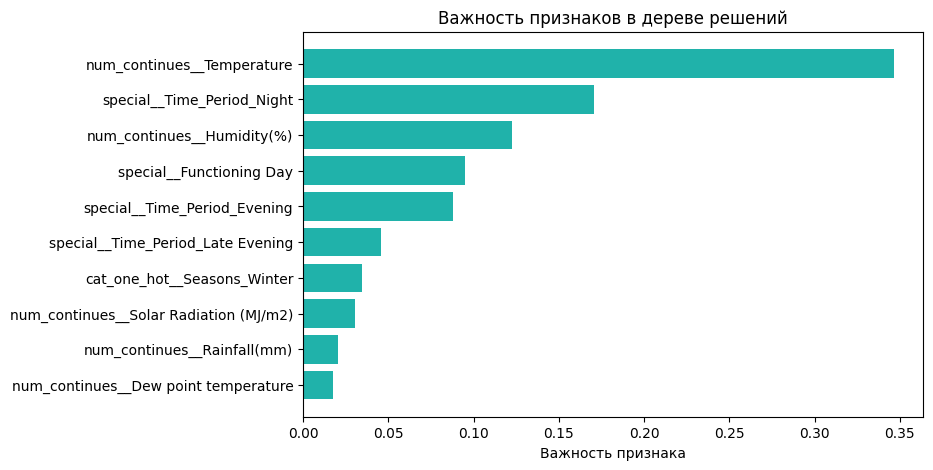

,feature,importance
4,num_continues__Temperature,0.346335
17,special__Time_Period_Night,0.170553
5,num_continues__Humidity(%),0.122701
13,special__Functioning Day,0.094904
14,special__Time_Period_Evening,0.087739
15,special__Time_Period_Late Evening,0.045650
3,cat_one_hot__Seasons_Winter,0.034341
9,num_continues__Solar Radiation (MJ/m2),0.030228
10,num_continues__Rainfall(mm),0.020628
8,num_continues__Dew point temperature,0.017562


In [91]:
show_feat_importance(best_pipeline)

Анализ:
- наиболее важный признак - температура воздуха (существенный отрыв от остальных почти в 2 раза)
- в топ-5 по важности: 
    - Temperature
    - Time_Period_Night
    - Humidity(%)
    - Functioning Day
    - Time_Period_Evening

Вывод:
- спрос на прокат велосипедов зависит больше всего от температуры, влажности, рабочий или выходной день, от времени суток

---
## 8. Сохранение итоговой модели

In [92]:
# обученный пайплайн с лучшей моделью
joblib.dump(best_pipeline, 'best_pipeline.joblib')

['best_pipeline.joblib']

#### Проверка

In [93]:
# загрузка 
loaded_pipeline = joblib.load('best_pipeline.joblib')

In [94]:
# пример предсказания модели
y_pred = loaded_pipeline.predict(X_test)

In [95]:
y_pred

array([ 335.38333333,  167.09677419,  289.31372549, ...,  108.41176471,
        207.66666667, 1940.50819672])

- предсказания получены, модель сохранена, скачивается и запускается корректно

---
## 9. Выводы и рекомендации заказчику


### Итоги:

Базовая модель.

- успешно загружена базовая модель, проверено ее качество
- показаетли базовой модели на test: MAE = 312.6, RMSE=411.56, R2=0.586  - высокие показатели средних ошибок и низкая способность описывать вариацию в данных

ИАД.

- загружен train датасет. Он содердит:
    - в датасете для обучения содержится 7008 объектов, 15 признаков, 1 целевая переменная.
    - 7 категориальных, 8 числовых признаков, целевая переменная в виде числа.
    - есть малочисленные пропуски 2% до 4% в столбцах Humidity(%), Wind speed (m/s), Visibility (10m),  Solar Radiation (MJ/m2), Rainfall(mm), Snowfall (cm). Пропуски решено заменить на статистики распределений. Неявных пропусков не обнаружено
    - дубликатов в данных не обнаружено
    - распределение целевой переменной несимметрично
    - среди признаков имеются выбросы, но используемые нелинейные модели устойчивы к ним
    - высоко скоррелированных между собой признаков нет
    - наиболее скоррелированный с таргетом признак: Temperature (corr=0.6)
- по итогам ИАД сформулированы предложения по предобработке:
    - фильтрацию по корреляции не применяем, нет проблем с мультиколлинеарностью 
    - категориальные признаки, которые по смыслу явяются флагами стоит заменить на [0, 1]:  'Holiday', 'Functioning Day', 'Time_Period_*'


Предобработка данных.

- построен пайплайн предобработки с опциональным масштабированием признаков 
- применяется OneHot кодирование категориальных признаков

Обучение базовых нелинейных моделей.

- обучены два вида моделей с использованием кросс-валидации: KNeighborsRegressor - с масштабированием признаков и DecisionTreeRegressor - без масштабирования
- по мерикам DecisionTreeRegressor можно сделать вывод, что она существенно переобучилась (нулевые RMSE, MAE и единичный R2 на train фолдах), при этом на  validate фолдах идет резкое ухудщение по метрикам. Итог: требуется оптимизация гипер параметров, чтобы уйти от переобучения.
- KNeighborsRegressor базовые метрики лучше (нет сильного переобучения), но также рекомендована оптимизация гипер параметров

Оптимизация гиперпараметров.

- проведена оптимизация с помощью библиотеки optuna

- результаты для DecisionTreeRegressor:
    - в ходе оптимизации параметров удалось существенно снизить среднее MAE на тестовых фолдах: уменьшение на 20%, MSE снизился на 25%
    - разница по метрикам test и train фолдами умеренная, в районе 10-15%. Это говорит об отсутсвии сильного переобучения
    - усредненная метрика R2 существенно увеличилась (прирост на 20%). Теперь модель объяснеяет существенно большую вариацию данных

- результаты для KNeighborsRegressor:
    - среднее MAE снизилась на 7% для теста и ушло в 0 для тренировочной выборки
    - среднее MSE снизилась на 6% для теста и ушло в 0 для тренировочной выборки
    - среднее R2 достигло 1 не train и незначительно увеличилось на 3% для test-овых фолдов

Лучшая модель:

- среди оптимизированных моделей выбрана лучшая: DecisionTreeRegressor

- Метрики лучшей модели на тестовых данных:
    - MAE = 210
    - RMSE = 314
    - R2 = 0.76

- Разница с существующей базовой линейной моделью:
    - MAE: снижение на 32%
    - RMSE: снижение на 24%
    - R2: увеличение на 23%

Наиболее важные признаки.

- проведена оценка наиболее важных для модели признаков:
    - наиболее важный признак - температура воздуха (существенный отрыв от остальных почти в 2 раза)
    - в топ-5 по важности: 
        - Temperature
        - Time_Period_Night
        - Humidity(%)
        - Functioning Day
        - Time_Period_Evening

Сохранение для продакшена

- разработанная модель сохранена с помощью joblib
- сохранение проверено


### Рекомендации

Разработанную модель можно рекомендовать к внедрени, поскольку она:

- учитывает нелинейные взаимосвязи между признаками
- существенно выше по качеству по ключевым метрикам MAE, RMSE, R2 (выйгрыш более 20%) по сравнению с базовой линейной моделью

На какие признаки стоит обрабить внимание:

- для точность прогноза спроса прокатного оборудования стоит обратить внимание на температуру воздуха - самый критически важный признак для модели
- к существенным признакам также относятся: влажность воздуха, время дня, выходной или рабочий день
